In [1]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
from numpy.linalg import eig
from scipy.interpolate import CubicSpline
import totalOrderMultiIndexSet
from sklearn.neighbors import KernelDensity
from numpy.polynomial.hermite_e import HermiteE
from matplotlib.lines import Line2D

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import cdsapi

plt.rcParams["figure.figsize"] = (10, 6)
import tqdm
import time

In [2]:
### Function Library ###

### APCEMM Pre-Sample ##########################################################################

def APCEMM_PS(LS_samples, placeholder, RH_supersat): #(number of samples, uncertain in time, uncertain IC)
    # need OD as a function of time, given an uncertain IC (or conditions), AKA matching results to inputs
    # return index matching  
    if RH_supersat == 80/76:
        return [0.45,
                0.82,
                1.18,
                1.53,
                1.86,
                2.19,
                2.52,
                2.83,
                3.13,
                3.47,
                3.82,
                4.15,
                4.49,
                4.84,
                5.19,
                5.54,
                5.9,
                6.24,
                6.6,
                6.97,
                7.33,
                7.71,
                8.1,
                8.5,
                8.9,
                9.3,
                9.69,
                10.0,
                10.4,
                10.69,
                10.91,
                10.91,
                10.76,
                10.6,
                10.36,
                10.02,
                9.67,
                9.33,
                8.99,
                8.64,
                8.28,
                7.92,
                7.54,
                7.23,
                6.99,
                6.8,
                6.63,
                6.41,
                6.11,
                5.77,
                5.41,
                5.06,
                4.7,
                4.36,
                4.02,
                3.69,
                3.38,
                3.12,
                2.9,
                2.73,
                2.66]
    else: 
        return [0.55,
                0.99,
                1.43,
                1.85,
                2.24,
                2.64,
                3.03,
                3.41,
                3.77,
                4.17,
                4.59,
                4.99,
                5.40,
                5.82,
                6.24,
                6.66,
                7.09,
                7.50,
                7.93,
                8.81,
                9.27,
                9.75,
                10.25,
                10.76,
                11.26,
                11.77,
                12.27,
                12.66,
                13.17,
                13.54,
                13.82,
                13.82,
                13.63,
                13.42,
                13.12,
                12.69,
                12.24,
                11.81,
                11.38,
                10.93,
                10.48,
                10.02,
                9.54,
                9.14,
                8.84,
                8.60,
                8.38,
                8.10,
                7.72,
                7.29,
                6.83,
                6.39,
                5.93,
                5.50,
                5.07,
                4.65,
                4.25,
                3.92,
                3.64,
                3.43,
                3.34]
    
    #OD = #[num of uncertain IC tested, num of timesteps]
    
    #return OD #function of time

####################################################################################

### PCE ############################################################################

def MC_LS(MC_runs, LS_samples, stoch_dim, sample_points, poly_deg):
    
    print("Started!")
    print("--- %s minutes elapsed ---" % round(time.time()/60 - start_time/60,2))
    
    n_trunc = stoch_dim - 1 #true if no IC?
    quad_points, quad_weights, lambda_hat, psi = nystrom_method(max_deg) # Sample from gaussian process
    psi = interpolate_phi(psi, lambda_hat, sample_points, quad_points, quad_weights)
    
    print("Got eigenvalues and eigenfunctions!")
    print("--- %s minutes elapsed ---" % round(time.time()/60 - start_time/60,2))
    
    #Evaluate the LS
    FZ_eval = get_FZ_APCEMM(MC_runs, stoch_dim) # Sample from gaussian distributions (how diff from nystrom?)
    
    c, alpha_set = compute_c(LS_samples, stoch_dim, poly_deg) #stochastic vs polynomial degree?
    
    print("Got c and alpha!")
    print("--- %s minutes elapsed ---" % round(time.time()/60 - start_time/60,2))
    
    He_array = np.zeros((alpha_set.shape[0], MC_runs)) # Number of rows (AKA # of coefficients) by number of MC simulations
    u_evals = np.zeros((MC_runs, max_deg)) # Number of MC runs of u function by the max polynomial degree (?)
    
    print("Started MC runs!")
    print("--- %s minutes elapsed ---" % round(time.time()/60 - start_time/60,2))
    for i in tqdm.tqdm(range(MC_runs)): # for each MC run
        for j in range(alpha_set.shape[0]): # for each coefficient
            current_alpha = alpha_set[j, :] # look at one row at a time for all alpha describing a single coefficient
            FZ_He = np.hstack( (np.array([(FZ_eval[i, 0] - mu_F)/sigma_F]), FZ_eval[i, 1:]) )
            He_array[j, i] = compute_He(FZ_He, current_alpha)
               
        k = np.exp(KL_expansion(sample_points, FZ_eval[i, 1:n_trunc+1], quad_points, lambda_hat[:n_trunc], psi[:, :n_trunc], quad_weights, interp = False)) # K = exp(Y)
        u_evals[i, :] = APCEMM_PS(LS_samples, k, FZ_eval[i, 0]) #sample_points, [FZ_eval[i, 0]], k
        
    u_LS = c.T @ He_array
    
    return u_LS.T, u_evals

def compute_c(LS_samples, stoch_dim, poly_deg):
    n_points = 61 #was 101
    
    FZ = get_FZ(LS_samples, stoch_dim)
    alpha_set = get_alpha_set(FZ.shape[1], poly_deg, "total")
    
    V = np.zeros((LS_samples, alpha_set.shape[0]))

    for i in tqdm.tqdm(range(LS_samples)):
        for j in range(alpha_set.shape[0]):
            current_alpha = alpha_set[j, :]
            FZ_He = np.hstack( (np.array([(FZ[i, 0] - mu_F)/sigma_F]), FZ[i, 1:]) )
            V[i, j] = compute_He(FZ_He, current_alpha) / np.sqrt(np.product(sc.special.factorial(current_alpha)))
    
    f = solve_u(FZ, n_points)
    
    c = np.linalg.solve(V.T @ V, V.T @ f)
    
    return c, alpha_set

def solve_u(FZ, n_points):
    u_sol = np.zeros((FZ.shape[0], n_points))
    stoch_dim = FZ.shape[1] - 1
    
    quad_points, quad_weights, lambda_hat, psi = nystrom_method(n_points)
    psi = interpolate_phi(psi, lambda_hat, sample_points, quad_points, quad_weights)
    
    for i in range(FZ.shape[0]):
        k = np.exp(KL_expansion(sample_points, FZ[i, 1:], quad_points, lambda_hat[:stoch_dim], psi[:, :stoch_dim], quad_weights, interp = False))
        u_sol[i, :] = APCEMM_PS(LS_samples, k, FZ[i, 0])
    return u_sol

def get_FZ(n_samples, n_points):
    return np.hstack((np.random.normal(mu_F, sigma_F, size = (n_samples, 1)), np.random.normal(mean_Y, sigma_Y, size = (n_samples, n_points-1)))) # was 0,1

def get_FZ_APCEMM(n_samples, n_points):
    APCEMM_in_array = [[80/76], [74/76]]
    print(np.shape(APCEMM_in_array))
    return np.hstack((APCEMM_in_array, np.random.normal(mean_Y, sigma_Y, size = (n_samples, n_points-1)))) # was 0,1

def nystrom_method(stochastic_dim):
    
    quad_points, quad_weights = get_quad_GaussLeg(max_deg)
    lambda_hat, psi = solve_Nystrom_eigen(quad_points, quad_weights)
    
    
    idx_order = np.argsort(-lambda_hat)
    lambda_hat = lambda_hat[idx_order]
    psi = psi[:, idx_order]
    
    return quad_points, quad_weights, lambda_hat, psi

def solve_Nystrom_eigen(quad_points, quad_weights):
       
    W_sqrt = make_W_sqrt(quad_weights)
    C = make_C_matrix(quad_points)

    M = W_sqrt @ C @ W_sqrt # Matrix multiplication
    
    lambda_hat, phi = np.linalg.eigh(M)
    
    psi = np.linalg.inv(W_sqrt) @ phi # We turned the problem in its symetric from so we need to change the variable back
    
    return lambda_hat, psi

def make_C_matrix(quad_points):
    m = quad_points.size
    
    C = np.zeros((m,m))
    
    for i in range(m):
        for j in range(m):
            C[i,j] = cov_kernel(quad_points[i], quad_points[j])
            # There are faster ways to do this...
    
    return C

def make_W_sqrt(quad_weights):
    return np.diag(np.sqrt(quad_weights))

def get_quad_GaussLeg(degree, a = 0, b = 1):
    # [a,b] is the target domain of integration
    
    x, w = np.polynomial.legendre.leggauss(degree) # Gives the weights for [-1,1]
    
    #x_scaled, w_scaled = 0.5 * (x + 1) * (b - a) + a, w * 0.5 * (b - a) 
    x_scaled, w_scaled = 0.5 * x + 0.5 , w * 0.5
    
    
    return x_scaled, w_scaled

def cov_kernel(x1, x2):
    return sigma_Y**2 * np.exp(-1/p * (np.abs(x1 - x2)/L)**p)

def interpolate_phi(psi, lambdas, s_points, quad_points, quad_weights):
    
    psi_interp = np.zeros((s_points.size, psi.shape[1]))
    cov_at_s = np.zeros(quad_points.size)
    
    for i in range(psi.shape[1]):
        for j in range(s_points.size):
            current_s = s_points[j]
            psi_interp[j, i] = (1 / lambdas[i] * 
                                np.sum(cov_kernel(np.ones(quad_points.size) * current_s, quad_points)
                                       *psi[:, i]*quad_weights))   
        
    return psi_interp

def get_alpha_set(poly_dim, poly_max_deg, type_exp):

    return totalOrderMultiIndexSet.totalOrderMultiIndices(poly_dim,poly_max_deg)

def compute_He(Z, alpha):
    res = 1
    for alpha_i, z_i in zip(alpha, Z):
        res = res * HermiteE.basis(deg = alpha_i)(z_i)
    return res

def KL_expansion(s, Z, quad_points, lambda_hat, psi, quad_weights, interp = True):
    n = lambda_hat.size
        
    Y_realisation = mean_Y * np.ones(s.size)
    
    if interp:
        psi_interp = interpolate_phi(psi, lambda_hat, s, quad_points, quad_weights)
    else:
        psi_interp = psi
        
    
    for i in range(n):
        Y_realisation = Y_realisation + lambda_hat[i]**(1/2) * psi_interp[:, i] * Z[i]
        
    return Y_realisation # Y is the randomness of k described by a gaussian process over time


####################################################################################

In [3]:
### Define Constants ###

MC_runs = 2
LS_samples = 60
n_trunc = 61 # KL truncation level
stoch_dim = 5 #n_trunc # number of uncertain inputs (the gaussian process dimension)
sample_points = np.linspace(0,1,n_trunc)
poly_deg = 2
max_deg = n_trunc
p = 5 #total degree (sum of max degrees)
Z = np.random.normal(0, 1, size = max_deg)

#RH (hum_scale)
mean_Y = 1 
sigma_Y = 0.1 #squared value?
L = 0.3

# nvPM
mu_F = 1 # mean nvPM initial
sigma_F = 0.3

In [4]:
### Call PCE Function ###
# nvpm is a function of time (soot is not constant)
start_time = time.time()
u_LS, u_evals = MC_LS(MC_runs, LS_samples, stoch_dim, sample_points, poly_deg)

Started!
--- 0.0 minutes elapsed ---
Got eigenvalues and eigenfunctions!
--- 0.0 minutes elapsed ---
(2, 1)


100%|██████████| 60/60 [00:00<00:00, 271.32it/s]


Got c and alpha!
--- 0.01 minutes elapsed ---
Started MC runs!
--- 0.01 minutes elapsed ---


100%|██████████| 2/2 [00:00<00:00, 247.63it/s]


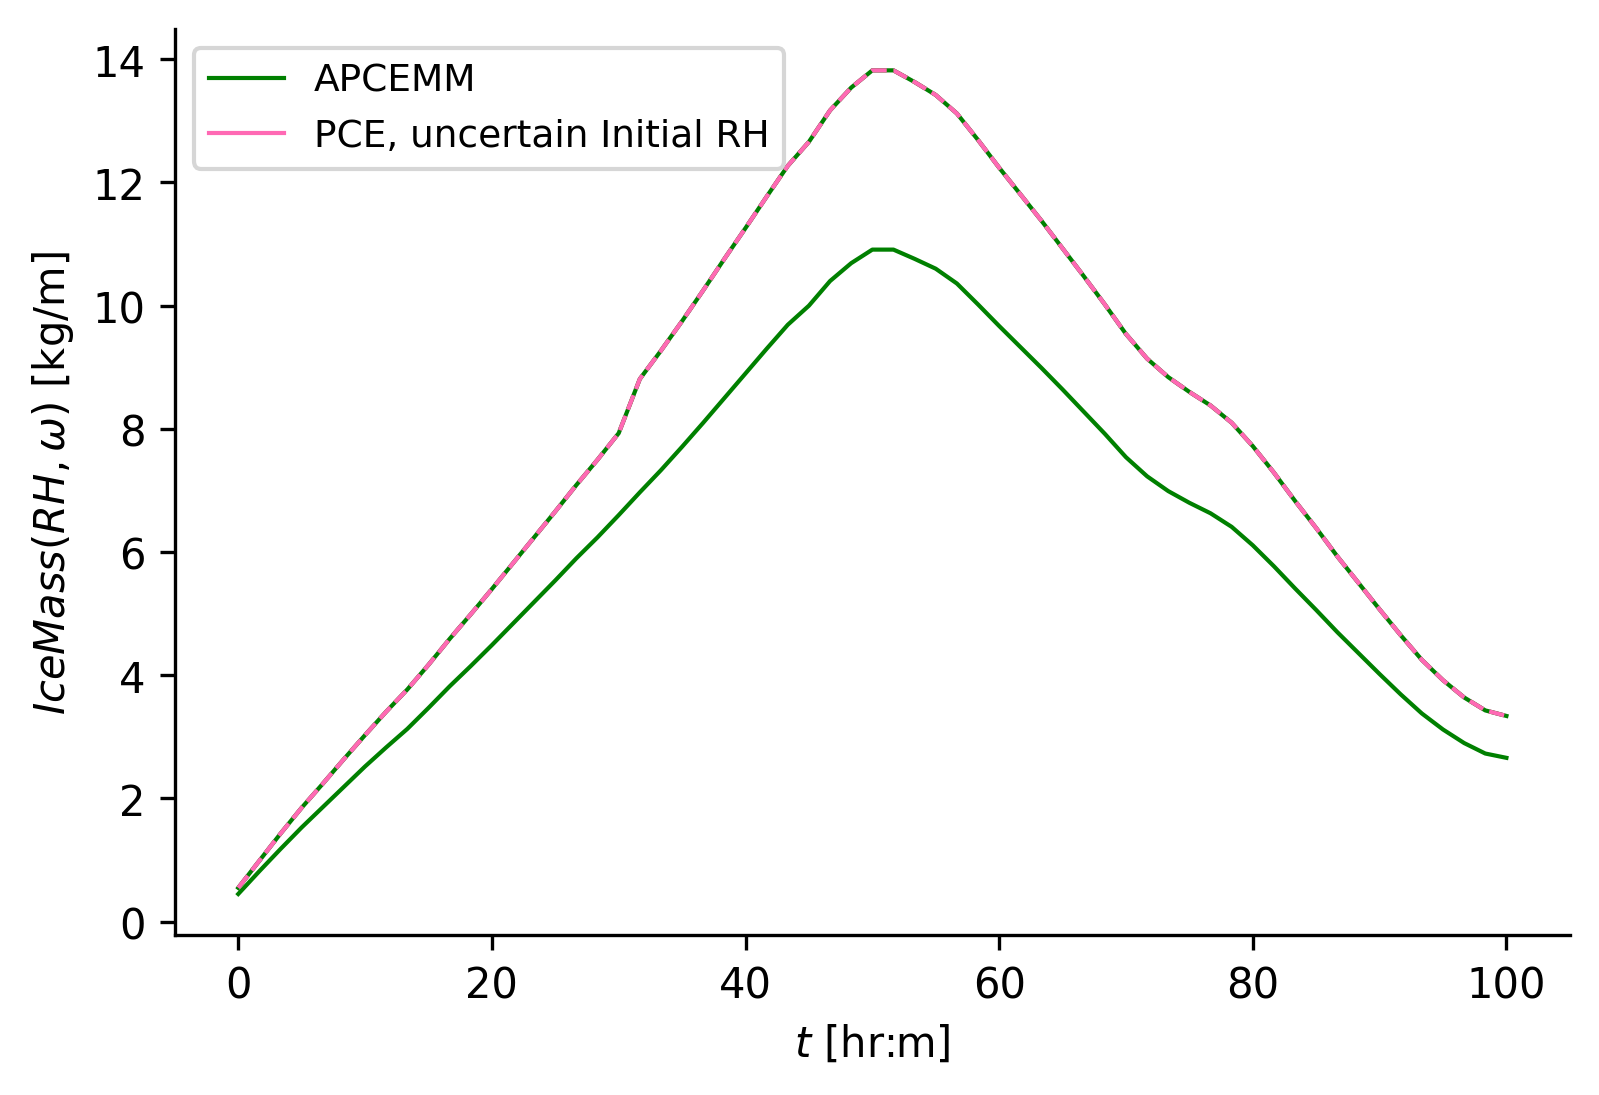

In [5]:
lw = 1
fig, ax = plt.subplots(dpi = 300)
for idx in range(2):
    #ax.plot(df.time, df.ef, label = "EF exact", color = "green", lw = lw)
    ax.plot(np.linspace(0, 100, 61), u_evals[idx, :], label = "EF exact", color = "green", lw = lw)
    ax.plot(np.linspace(0, 100, 61), u_LS[idx, :], label = "EF PCE", color = "hotpink", ls = "dashed", lw = lw)

# ax.set_xlim(0,1)
ax.set_xlabel(xlabel = r"$t$ [hr:m]")
ax.set_ylabel(ylabel = r"$Ice Mass(RH, \omega)$ [kg/m]")

custom_lines = [Line2D([0], [0], color="green", lw=1), Line2D([0], [0], color="hotpink", lw=1)] # 

ax.legend(custom_lines, ['APCEMM', 'PCE, uncertain Initial RH'], fontsize = 9)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)


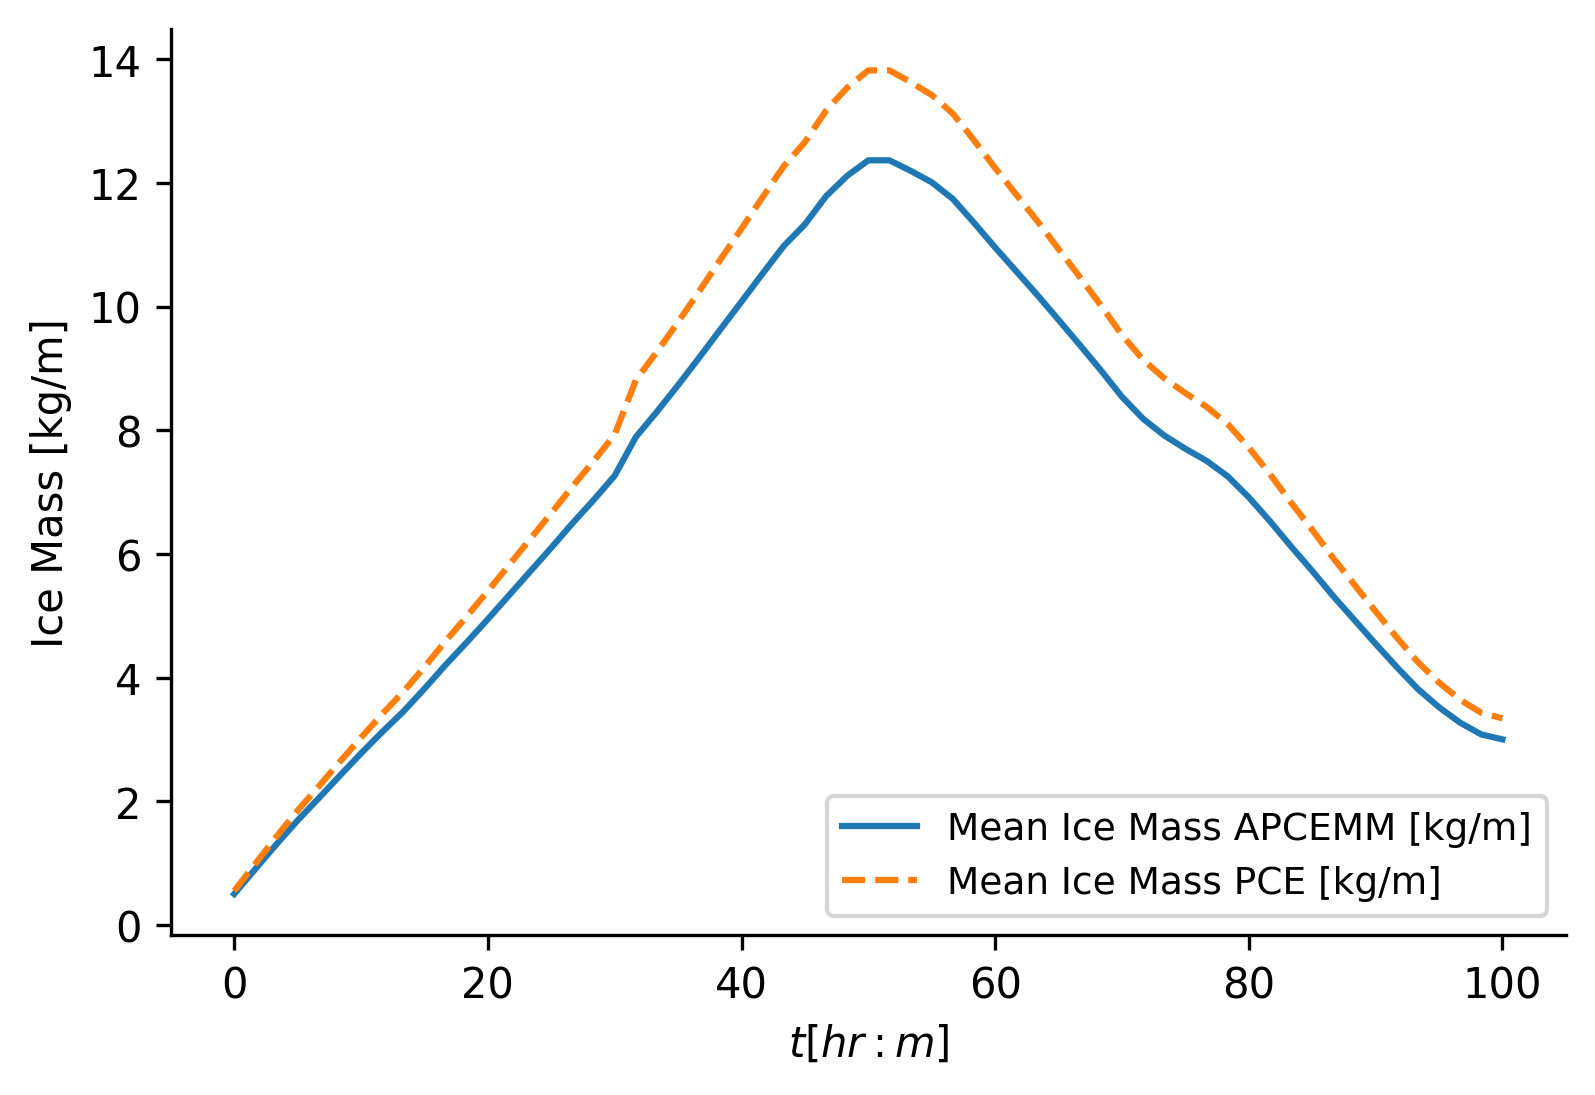

In [6]:
fig, ax = plt.subplots(dpi = 300)
ax.plot(np.linspace(0, 100, 61), np.mean(u_evals, axis = 0), label = "Mean Ice Mass APCEMM [kg/m]")
ax.plot(np.linspace(0, 100, 61), np.mean(u_LS, axis = 0), label = "Mean Ice Mass PCE [kg/m]", ls = "dashed")
ax.legend(fontsize = 9)
# ax.set_xlim(0,1)
ax.set_xlabel(xlabel = r"$t [hr:m]$")
ax.set_ylabel(ylabel = r"Ice Mass [kg/m]")

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

NameError: name 'k' is not defined

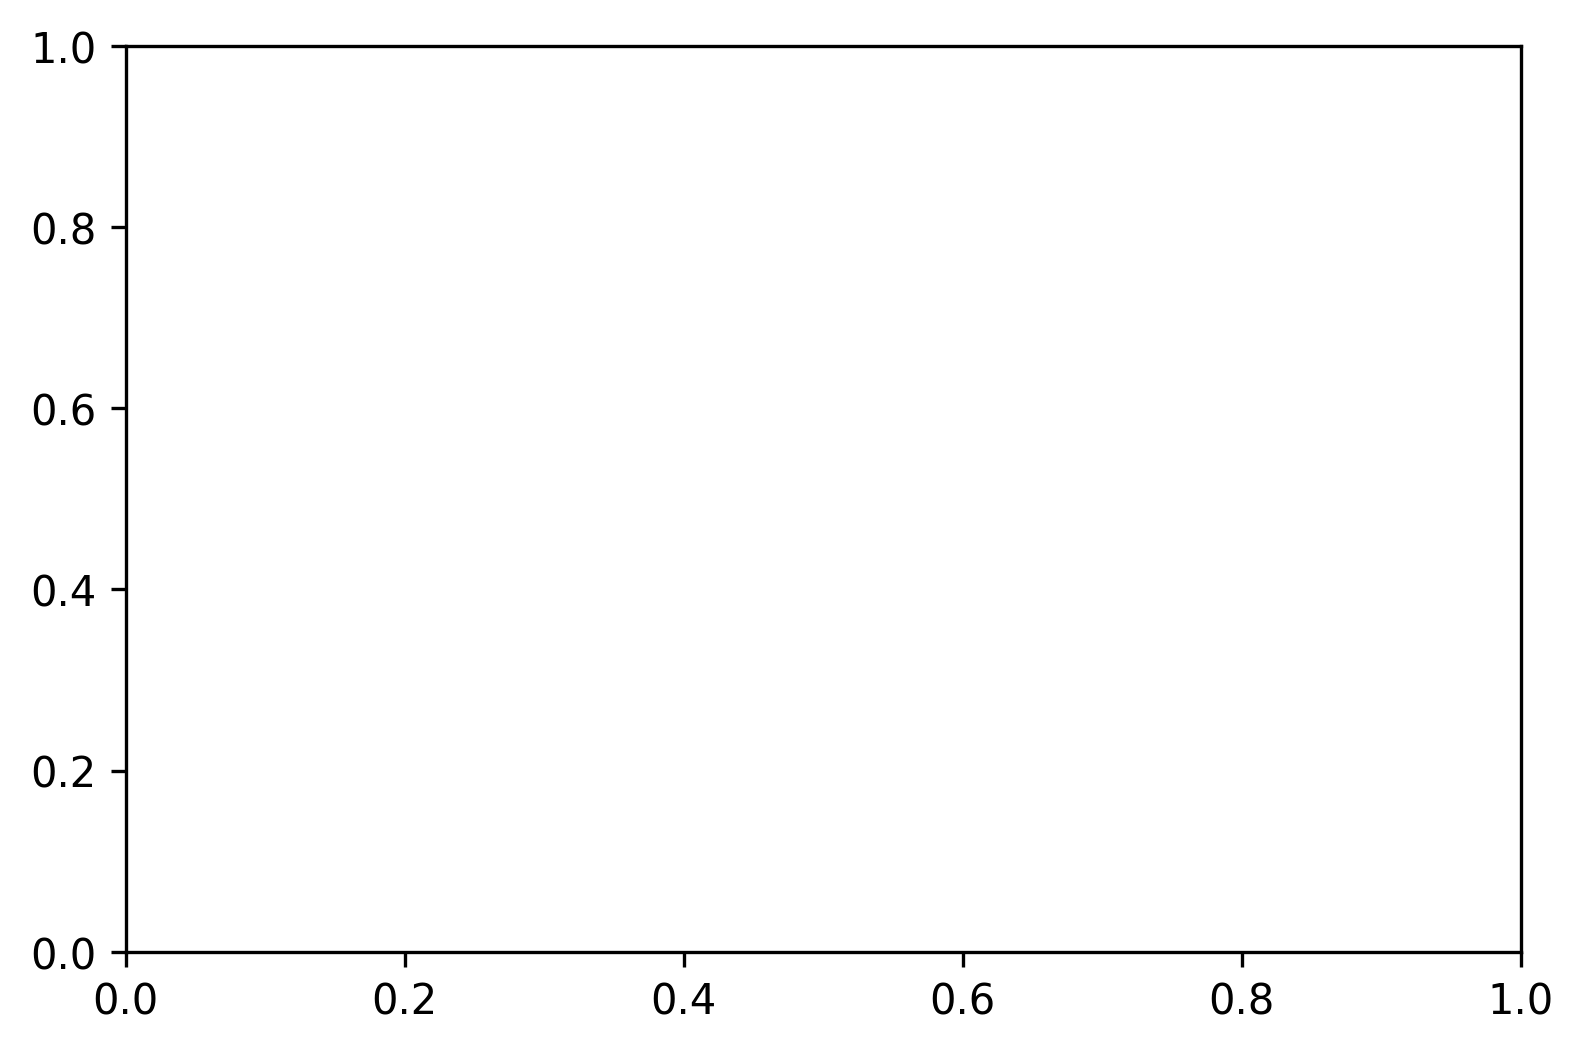

In [7]:
# quad_points, quad_weights, lambda_hat, psi = nystrom_method(max_deg) # Sample from 5D gaussian
# psi = interpolate_phi(psi, lambda_hat, sample_points, quad_points, quad_weights)

# full_Y = KL_expansion(sample_points, Z, quad_points, lambda_hat, psi, quad_weights)
# k = np.exp(full_Y)

lw = 1
fig, ax = plt.subplots(dpi = 300)
for idx in range(100):
    ax.plot(sample_points, k, label = "EF exact", color = "green", lw = lw)
    #ax.plot(sample_points, u_LS[idx, :], label = "EF PCE", color = "hotpink", ls = "dashed", lw = lw)

# ax.set_xlim(0,1)
ax.set_xlabel(xlabel = r"$t$")
ax.set_ylabel(ylabel = r"$EF(x, \omega)$")

custom_lines = [Line2D([0], [0], color="green", lw=1), 
                Line2D([0], [0], color="hotpink", lw=1)]

ax.legend(custom_lines, ['CoCiP solution', 'PCE'], fontsize = 9)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

In [ ]:
def make_ABC_LS(m, sample_points):
    N_samples_LS = 1000
    stoch_dim = 5
    poly_deg = 2
    
    n_points = sample_points.size
    
    n_params = n_points + 1 
    
    F1 = np.random.normal(mu_F, sigma_F, size = (m, 1))
    F2 = np.random.normal(mu_F, sigma_F, size = (m, 1))
    
    A = np.hstack((F1, np.random.normal(0, 1, size = (m, n_points))))
    B = np.hstack((F2, np.random.normal(0, 1, size = (m, n_points))))
    
    C = np.zeros((n_params, m , n_params))
    
    for i in range(n_params):
        C[i, :, :] = B
        C[i, :, i] = A[:, i]
        
    y_A = np.zeros(m, dtype = np.float32)
    y_B= np.zeros(m, dtype = np.float32)
    y_C = np.zeros((n_params, m), dtype = np.float32)
    
    c, alpha_set = compute_c(N_samples_LS, stoch_dim, poly_deg)
    
    
    for i in tqdm.tqdm(range(m)):
        y_A[i] = evaluate_LS(c, alpha_set, A[i, :])[50]
        y_B[i] = evaluate_LS(c, alpha_set, B[i, :])[50]
                          
        for j in range(n_params):
            y_C[j, i] = evaluate_LS(c, alpha_set, C[j, i, :])[50]
    
    return y_A, y_B, y_C

In [ ]:
y_A_LS, y_B_LS, y_C_LS = make_ABC_LS(10, sample_points)

In [ ]:
f0sq_LS = get_f_0_sq(sample_points.size, y_A_LS)
S_LS = np.array([get_S_i(sample_points.size, y_A_LS, y_C_LS[i], f0sq_LS) for i in range(102)])
S_T_LS = np.array([get_S_Ti(sample_points.size, y_A_LS, y_B_LS, y_C_LS[i], f0sq_LS) for i in range(102)])

In [ ]:
S1_LS,S_T1_LS = S_LS[0], S_T_LS[0]
S2_LS, S_T2_LS = np.sum(S_LS[1:]), np.sum(S_T_LS[1:])
S12_LS = -0.5 * (S_T1_LS - S1_LS  + S_T2_LS - S2_LS)
main_effect_S_LS = np.array([S1_LS, S2_LS, S12_LS])
tot_effect_ST_LS = np.array([S_T1_LS, S_T2_LS])

In [ ]:
fig, ax = plt.subplots(dpi = 300)
ax.bar(np.arange(0, 3), main_effect_S_LS/main_effect_S_LS.sum(), width = 0.5, alpha = 0.8)
ax.set_xticks(np.arange(0, 3), [r"$S_F$", r"$S_k$", r"$S_{F, k}$"])
ax.set_yticks(np.linspace(0, 1, 11), np.linspace(0, 100, 11, dtype = int))
ax.set_ylabel(ylabel = r"% Contribution to $u(x = 0.5)$")
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

In [ ]:
fig, ax = plt.subplots(dpi = 300)
ax.bar(np.arange(0, 2), tot_effect_ST_LS/tot_effect_ST_LS.sum(), width = 0.5, alpha = 0.8)
ax.set_xticks([0, 1], [r"$S_{T_F}$", r"$S_{T_k}$"])
ax.set_yticks(np.linspace(0, 1, 11), np.linspace(0, 100, 11, dtype = int))
ax.set_ylabel(ylabel = r"% Contribution to $u(x = 0.5)$")
ax.set_ylim(0, 1)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)